In [2]:
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


TEST_CONFIGS = [
    ("burnin", 0),
    ("burnin", 400),
    ("burnin", 700),
    ("burnin", 1000),
    ("burnin", 1300),
    ("warmup", 3125),
]

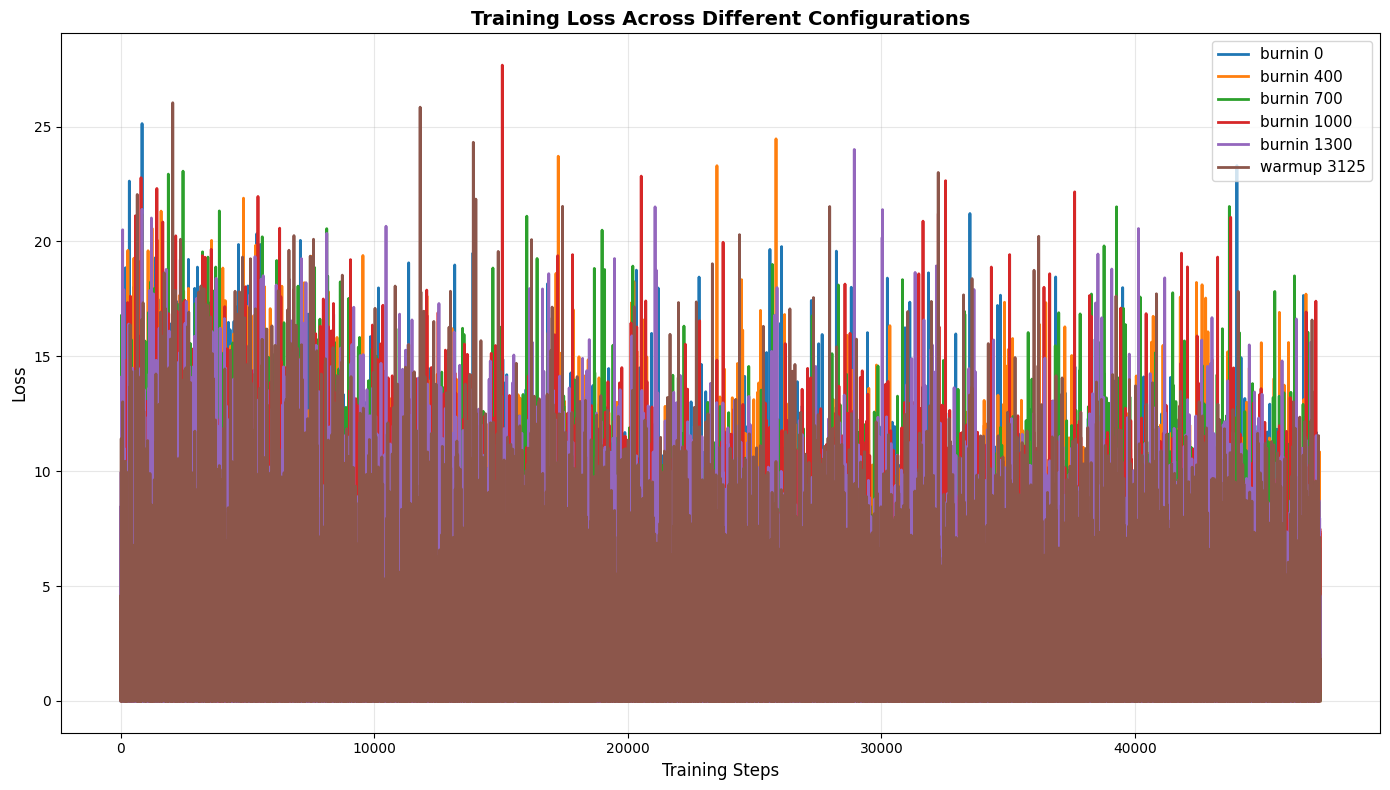

In [12]:
plt.figure(figsize=(14, 8))

for name, steps in TEST_CONFIGS:
    try:
        train_loss_data = np.loadtxt(f"results/burnin_warmup/train_loss_{name}_{steps}.txt")
        plt.plot(train_loss_data, label=f"{name} {steps}", linewidth=2)
    except FileNotFoundError:
        print(f"File not found: train_loss_{name}_{steps}.txt")

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Loss Across Different Configurations", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

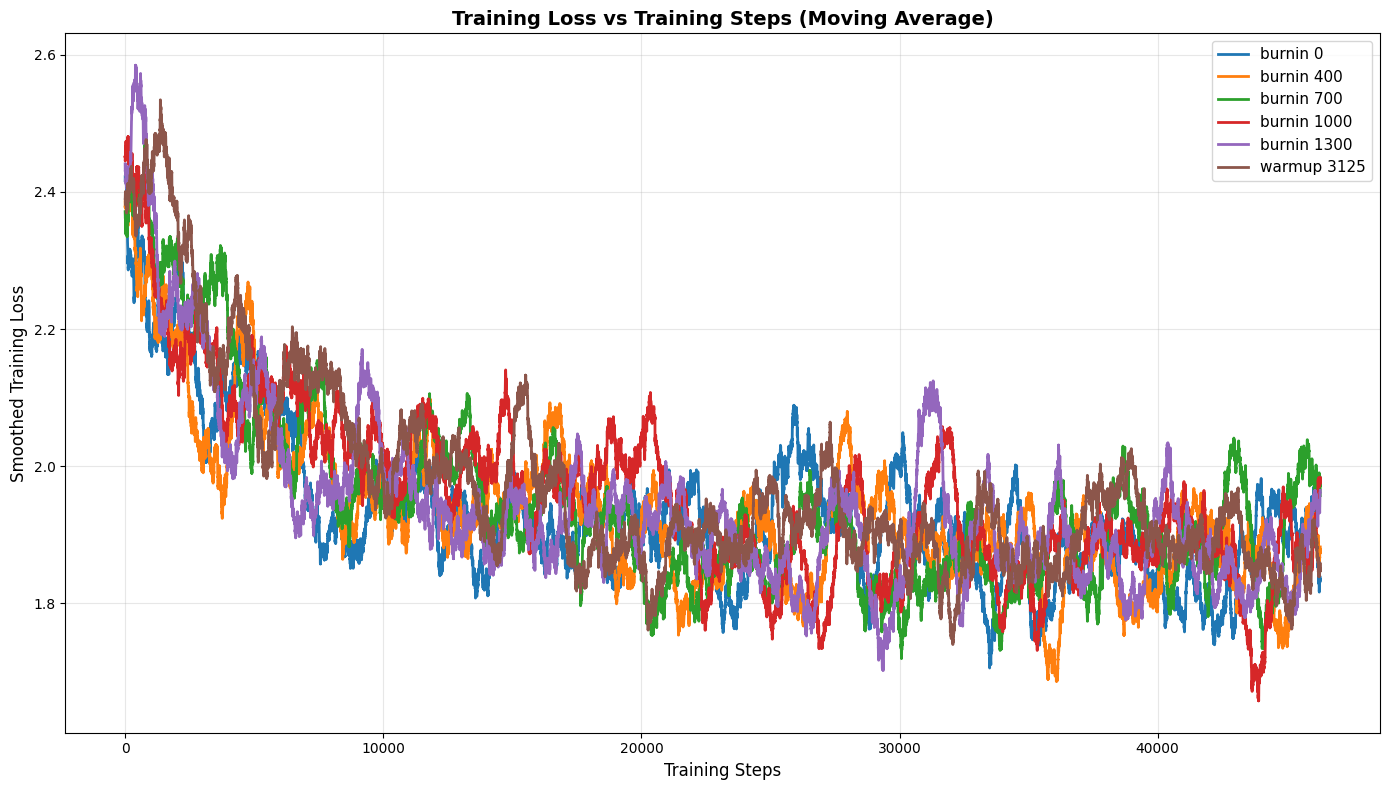

In [13]:
def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, steps in TEST_CONFIGS:
    try:
        train_loss_data = np.loadtxt(f"results/burnin_warmup/train_loss_{name}_{steps}.txt")
        
        smoothed_acc = smooth_curve(train_loss_data, window_size=1000)
        steps_x = np.arange(len(smoothed_acc))
        
        plt.plot(steps_x, smoothed_acc, label=f"{name} {steps}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Training Loss", fontsize=12)
plt.title("Training Loss vs Training Steps (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

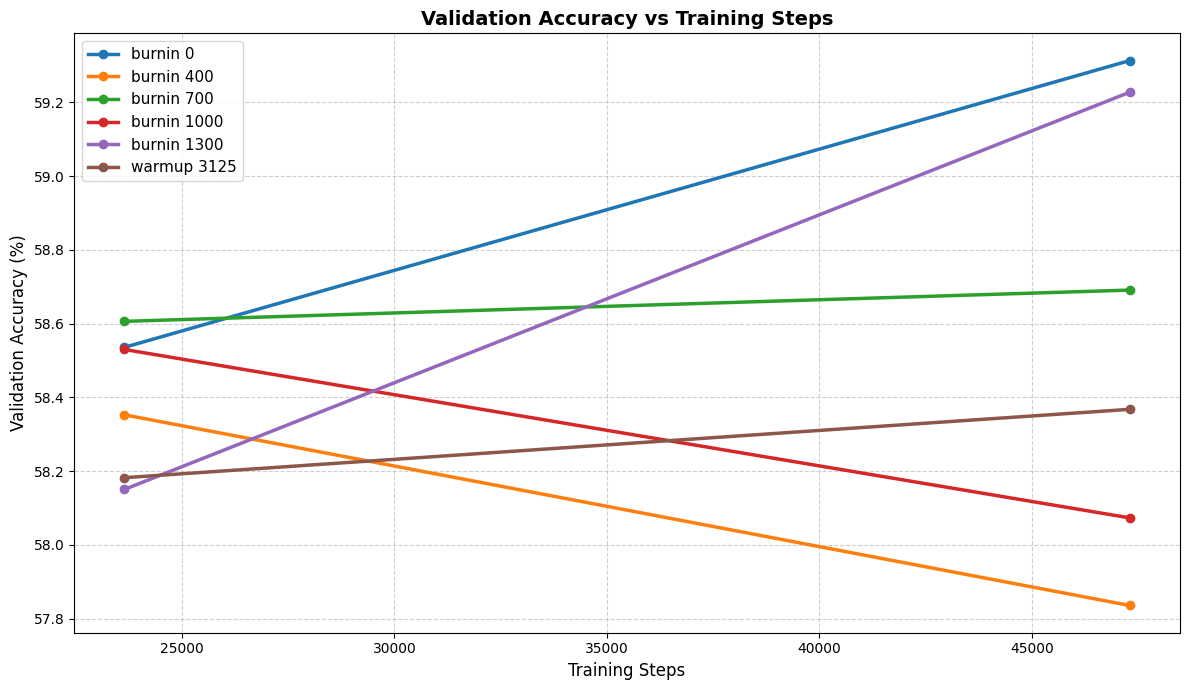

In [ ]:
plt.figure(figsize=(12, 7))

for name, steps in TEST_CONFIGS:
    try:
        val_acc_data = np.loadtxt(f"results/burnin_warmup/val_acc_{name}_{steps}.txt")
        train_loss_data = np.loadtxt(f"results/burnin_warmup/train_loss_{name}_{steps}.txt")
        
        epochs_count = len(val_acc_data)
        total_steps = len(train_loss_data)
        steps_per_epoch = total_steps // epochs_count
        
        steps_x = np.arange(1, epochs_count + 1) * steps_per_epoch
        
        plt.plot(steps_x, val_acc_data * 100, label=f"{name} {steps}", marker='o', linewidth=2.5)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.title("Validation Accuracy vs Training Steps", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

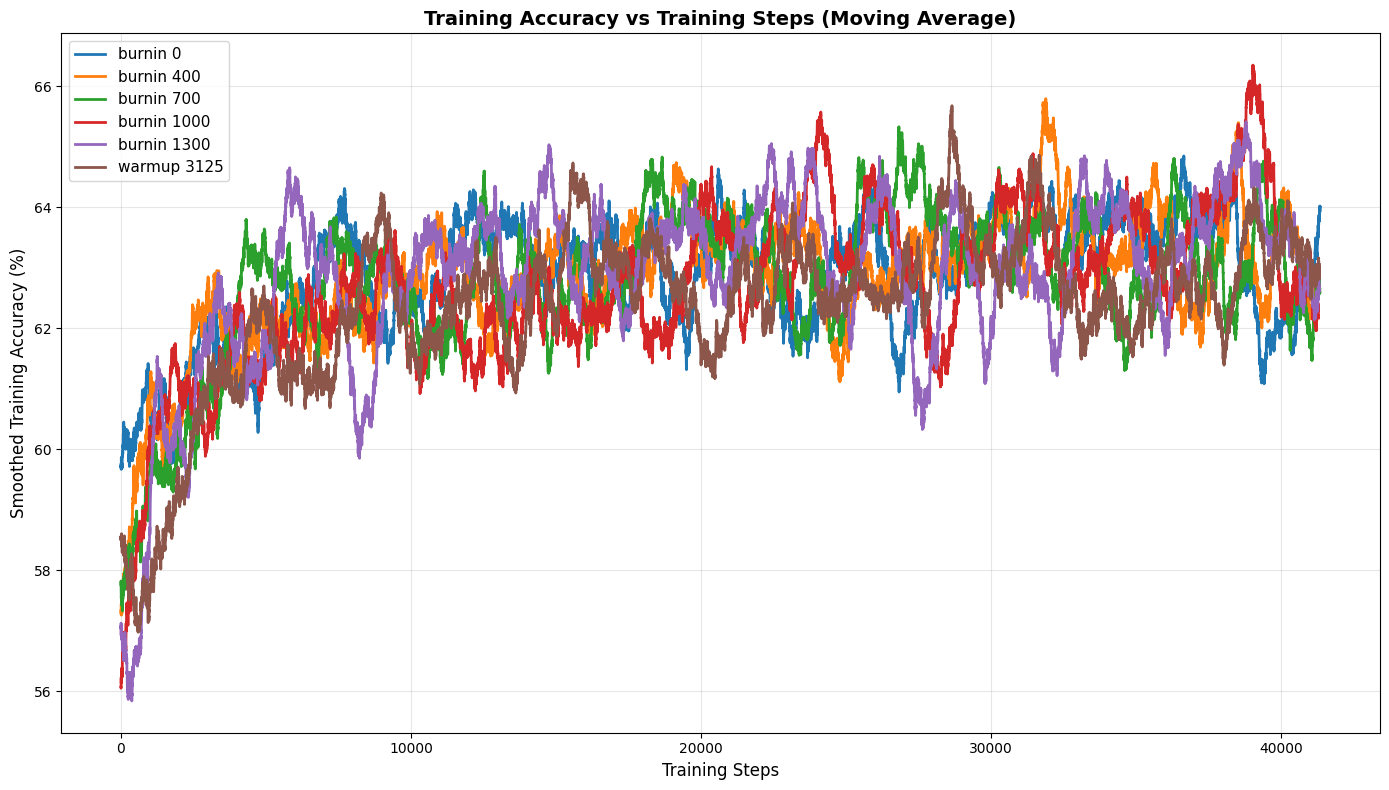

In [ ]:
def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, steps in TEST_CONFIGS:
    try:
        train_acc_data = np.loadtxt(f"results/burnin_warmup/train_acc_{name}_{steps}.txt")
        
        smoothed_acc = smooth_curve(train_acc_data * 100, window_size=1000)
        steps_x = np.arange(len(smoothed_acc))
        
        plt.plot(steps_x, smoothed_acc, label=f"{name} {steps}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Training Accuracy (%)", fontsize=12)
plt.title("Training Accuracy vs Training Steps (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()